In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["num_chains"]))
print(config_str)

N10_H20_delta_c2.00_num_samples100000_num_chains4_a1.50_b0.27


In [5]:
samples=[10.1, 11.0, 8.2, 11.1, 22.5, 13.3, 13.8, 14.2, 14.6, 6.5]

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

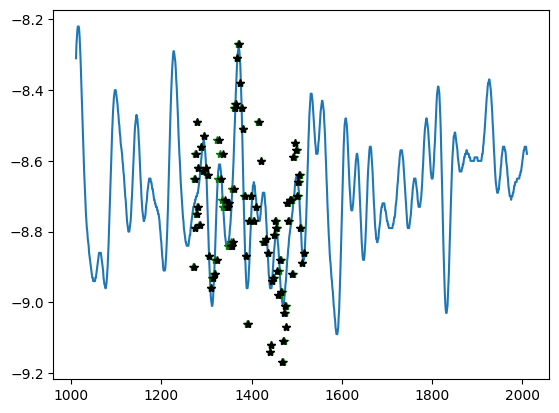

In [6]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
d18O_ages = expected_ages(config["N"], config["delta_c"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], samples, indices)
plt.plot(d18O_ages, data["d18O"], '*', color = 'green')

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [7]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail  \
x[0]  10.07   1.06    8.10    12.10       0.00     0.00  130673.15  124738.48   
x[1]  11.35   1.84    7.85    14.79       0.01     0.00   28795.91   97171.89   
x[2]   7.44   2.48    2.75    12.36       0.25     0.14      96.81     199.43   
x[3]   8.76   5.12    0.03    14.85       2.23     0.89       6.54      31.64   
x[4]  20.46  19.85    0.24    53.69       9.85     4.61       5.20      30.74   
x[5]  16.08  16.69    0.04    44.83       8.29     4.39       4.92      24.27   
x[6]   7.71   5.37    0.06    15.45       2.48     0.44       5.64      40.93   
x[7]   9.04   6.31    0.19    18.12       2.99     0.29       5.71      31.20   
x[8]  28.05  20.76   11.52    67.10      10.31     5.93       5.51      25.20   
x[9]   5.91   5.97    0.00    20.39       0.86     1.56     174.31      31.58   

      r_hat  
x[0]   1.00  
x[1]   1.00  
x[2]   1.03  
x[3]   1.62  
x[4]   2.27  
x[5]   2.32  
x[6]   1.8

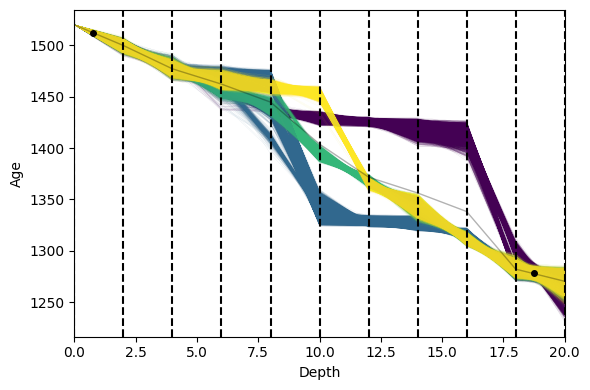

In [8]:
cumulative_sums = np.cumsum(samples[:, :,:], axis=2) * config["delta_c"]
zeros = np.zeros((*samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(samples[0,:,0])
for i in range(config["num_chains"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()